# AI-ML PROJECT - Building models for 'Turbofan Engine Degradation'

In [ ]:
pip install numpy pandas matplotlib seaborn scikit-learn plotly kagglehub torch

In [ ]:
# Dataset: NASA CMAPSS Turbofan Engine Degradation Simulation Dataset
# Download from: https://www.nasa.gov/intelligent-systems-division/discovery-and-systems-health/pcoe/pcoe-data-set-repository/
# After downloading, extract the zip file and place the .txt files in a folder.
# This project uses the files from: D:\CMAPSSData\
# Required files: train_FD001.txt, test_FD001.txt, RUL_FD001.txt

print("Dataset path: D:\\CMAPSSData\\")
print("Required files: train_FD001.txt, test_FD001.txt, RUL_FD001.txt")

Dataset path: D:\CMAPSSData\
Required files: train_FD001.txt, test_FD001.txt, RUL_FD001.txt


In [33]:
import pandas as pd
import numpy as np

col_names = ['unit_id', 'cycle', 'op1', 'op2', 'op3'] + [f's{i}' for i in range(1, 22)]

train = pd.read_csv(r"D:\CMAPSSData\train_FD001.txt", sep='\s+', header=None, names=col_names)
test  = pd.read_csv(r"D:\CMAPSSData\test_FD001.txt",  sep='\s+', header=None, names=col_names)
rul   = pd.read_csv(r"D:\CMAPSSData\RUL_FD001.txt",   sep='\s+', header=None, names=['RUL'])

print("Train shape:", train.shape)
print("Test shape: ", test.shape)
print(train.head())

Train shape: (20631, 26)
Test shape:  (13096, 26)
   unit_id  cycle     op1     op2    op3      s1      s2       s3       s4  \
0        1      1 -0.0007 -0.0004  100.0  518.67  641.82  1589.70  1400.60   
1        1      2  0.0019 -0.0003  100.0  518.67  642.15  1591.82  1403.14   
2        1      3 -0.0043  0.0003  100.0  518.67  642.35  1587.99  1404.20   
3        1      4  0.0007  0.0000  100.0  518.67  642.35  1582.79  1401.87   
4        1      5 -0.0019 -0.0002  100.0  518.67  642.37  1582.85  1406.22   

      s5  ...     s12      s13      s14     s15   s16  s17   s18    s19  \
0  14.62  ...  521.66  2388.02  8138.62  8.4195  0.03  392  2388  100.0   
1  14.62  ...  522.28  2388.07  8131.49  8.4318  0.03  392  2388  100.0   
2  14.62  ...  522.42  2388.03  8133.23  8.4178  0.03  390  2388  100.0   
3  14.62  ...  522.86  2388.08  8133.83  8.3682  0.03  392  2388  100.0   
4  14.62  ...  522.19  2388.04  8133.80  8.4294  0.03  393  2388  100.0   

     s20      s21  
0  39.06  

<>:6: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:7: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:8: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:6: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:7: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:8: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\aayus\AppData\Local\Temp\ipykernel_15476\816529229.py:6: SyntaxWarning: "

In [34]:
# Fix the separator warning
train = pd.read_csv(r"D:\CMAPSSData\train_FD001.txt", sep=r'\s+', header=None, names=col_names)
test  = pd.read_csv(r"D:\CMAPSSData\test_FD001.txt",  sep=r'\s+', header=None, names=col_names)
rul   = pd.read_csv(r"D:\CMAPSSData\RUL_FD001.txt",   sep=r'\s+', header=None, names=['RUL'])

# Add RUL column to training data
# For each engine, RUL = max_cycle - current_cycle
max_cycles = train.groupby('unit_id')['cycle'].max().reset_index()
max_cycles.columns = ['unit_id', 'max_cycle']
train = train.merge(max_cycles, on='unit_id')
train['RUL'] = train['max_cycle'] - train['cycle']
train.drop(columns=['max_cycle'], inplace=True)

print(train[['unit_id', 'cycle', 'RUL']].head(10))
print("\nMax RUL:", train['RUL'].max())
print("Min RUL:", train['RUL'].min())

   unit_id  cycle  RUL
0        1      1  191
1        1      2  190
2        1      3  189
3        1      4  188
4        1      5  187
5        1      6  186
6        1      7  185
7        1      8  184
8        1      9  183
9        1     10  182

Max RUL: 361
Min RUL: 0


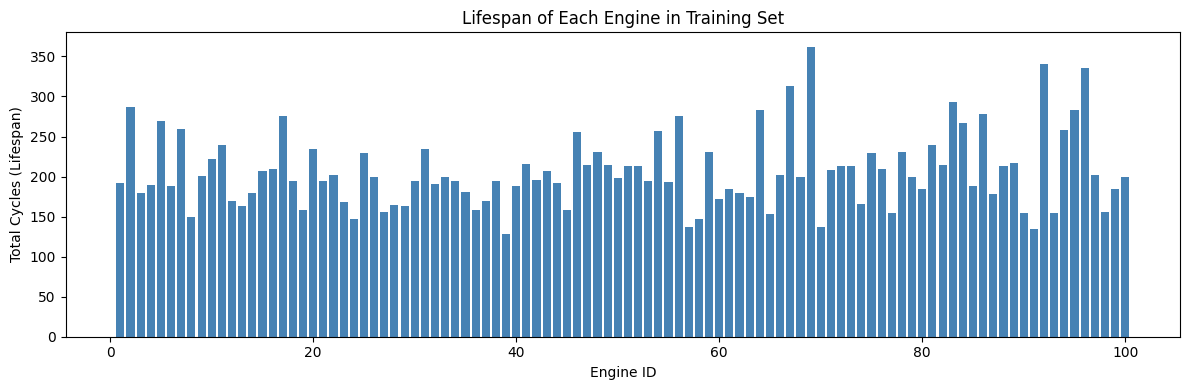

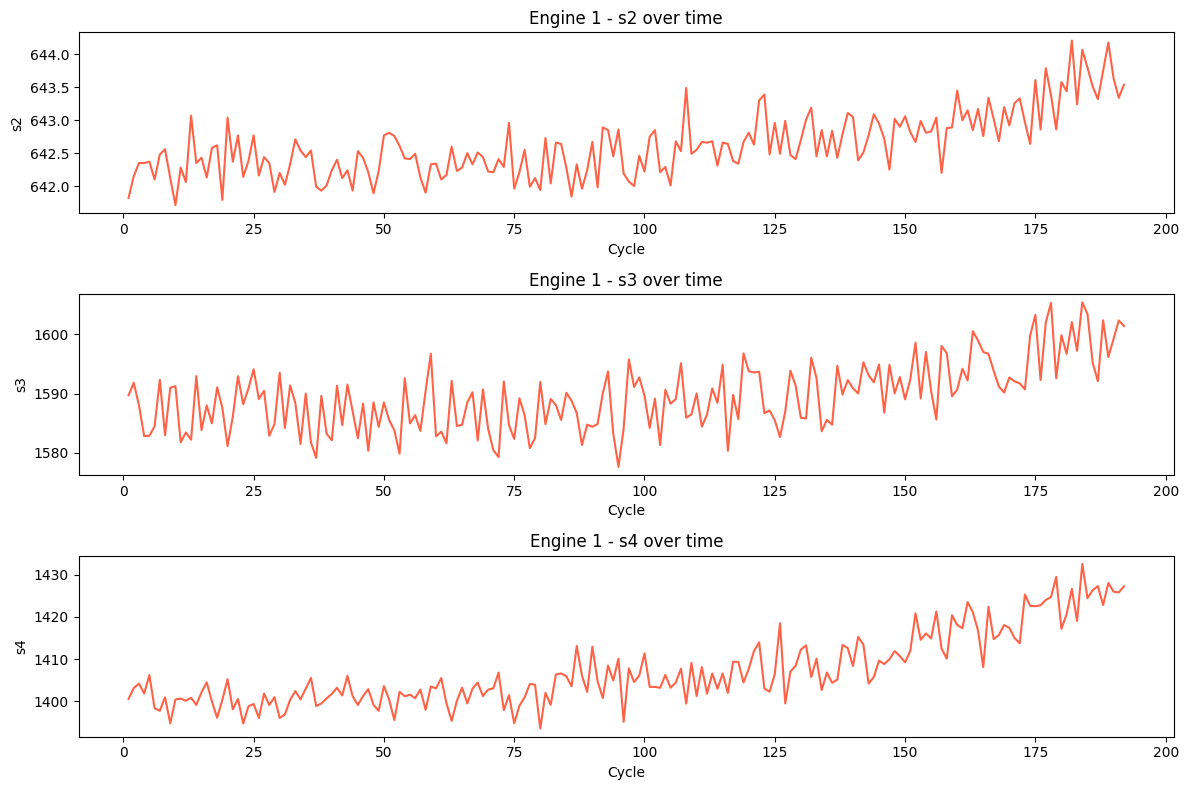

Number of unique engines: 100
Average engine lifespan: 206.3 cycles


In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. How long do engines last?
engine_life = train.groupby('unit_id')['cycle'].max()

plt.figure(figsize=(12, 4))
plt.bar(engine_life.index, engine_life.values, color='steelblue')
plt.xlabel('Engine ID')
plt.ylabel('Total Cycles (Lifespan)')
plt.title('Lifespan of Each Engine in Training Set')
plt.tight_layout()
plt.show()

# 2. Pick one engine and plot a few sensors over time
engine_1 = train[train['unit_id'] == 1]

fig, axes = plt.subplots(3, 1, figsize=(12, 8))
for i, sensor in enumerate(['s2', 's3', 's4']):
    axes[i].plot(engine_1['cycle'], engine_1[sensor], color='tomato')
    axes[i].set_title(f'Engine 1 - {sensor} over time')
    axes[i].set_xlabel('Cycle')
    axes[i].set_ylabel(sensor)
plt.tight_layout()
plt.show()

print("Number of unique engines:", train['unit_id'].nunique())
print("Average engine lifespan:", engine_life.mean().round(1), "cycles")

In [36]:
# Check which sensors have near-zero variance (not to be considered for ML)
sensor_cols = [f's{i}' for i in range(1, 22)]
variances = train[sensor_cols].var()

print("Sensor variances:")
print(variances.round(4))

# Drop sensors with very low variance
useful_sensors = variances[variances > 0.01].index.tolist()
useless_sensors = variances[variances <= 0.01].index.tolist()

print("\nUseful sensors:", useful_sensors)
print("Useless sensors (will drop):", useless_sensors)

Sensor variances:
s1       0.0000
s2       0.2501
s3      37.5910
s4      81.0109
s5       0.0000
s6       0.0000
s7       0.7834
s8       0.0050
s9     487.6536
s10      0.0000
s11      0.0713
s12      0.5440
s13      0.0052
s14    363.9005
s15      0.0014
s16      0.0000
s17      2.3987
s18      0.0000
s19      0.0000
s20      0.0327
s21      0.0117
dtype: float64

Useful sensors: ['s2', 's3', 's4', 's7', 's9', 's11', 's12', 's14', 's17', 's20', 's21']
Useless sensors (will drop): ['s1', 's5', 's6', 's8', 's10', 's13', 's15', 's16', 's18', 's19']


In [37]:
# Keep only useful sensors + metadata
useful_sensors = ['s2', 's3', 's4', 's7', 's9', 's11', 's12', 's14', 's17', 's20', 's21']

# Final training dataframe
train_clean = train[['unit_id', 'cycle', 'RUL'] + useful_sensors].copy()

# Normalize sensors (scale to 0-1 range so ML works better)
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
train_clean[useful_sensors] = scaler.fit_transform(train_clean[useful_sensors])

# Add anomaly label - last 30 cycles before failure = anomaly (1), rest = normal (0)
train_clean['anomaly'] = (train_clean['RUL'] <= 30).astype(int)

print(train_clean.head(10))
print("\nAnomaly distribution:")
print(train_clean['anomaly'].value_counts())
print(f"\nAnomaly %: {train_clean['anomaly'].mean()*100:.1f}%")

   unit_id  cycle  RUL        s2        s3        s4        s7        s9  \
0        1      1  191  0.183735  0.406802  0.309757  0.726248  0.109755   
1        1      2  190  0.283133  0.453019  0.352633  0.628019  0.100242   
2        1      3  189  0.343373  0.369523  0.370527  0.710145  0.140043   
3        1      4  188  0.343373  0.256159  0.331195  0.740741  0.124518   
4        1      5  187  0.349398  0.257467  0.404625  0.668277  0.149960   
5        1      6  186  0.268072  0.292784  0.272113  0.776167  0.125415   
6        1      7  185  0.382530  0.463920  0.261985  0.723027  0.167818   
7        1      8  184  0.406627  0.259865  0.316003  0.644122  0.085569   
8        1      9  183  0.274096  0.434707  0.211850  0.618357  0.110967   
9        1     10  182  0.150602  0.440375  0.307394  0.602254  0.134479   

        s11       s12       s14       s17       s20       s21  anomaly  
0  0.369048  0.633262  0.199608  0.333333  0.713178  0.724662        0  
1  0.380952  0.76

=== Isolation Forest Results ===
              precision    recall  f1-score   support

      Normal       0.95      0.95      0.95     17531
     Anomaly       0.71      0.71      0.71      3100

    accuracy                           0.91     20631
   macro avg       0.83      0.83      0.83     20631
weighted avg       0.91      0.91      0.91     20631



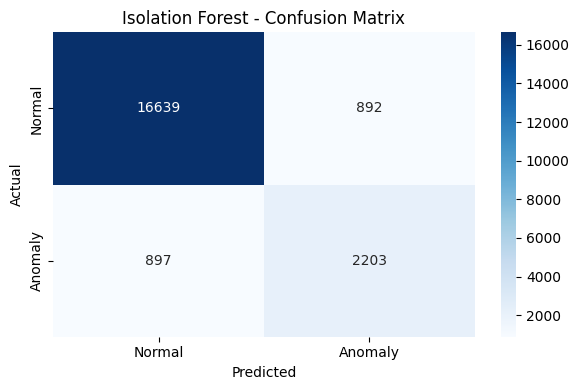

ROC-AUC Score: 0.9357


In [38]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# Features for the model
X_train = train_clean[useful_sensors].values
y_true  = train_clean['anomaly'].values

# Train Isolation Forest
iso_forest = IsolationForest(n_estimators=100, contamination=0.15, random_state=42)
iso_forest.fit(X_train)

# Predict - Isolation Forest outputs -1 (anomaly) or 1 (normal)
preds = iso_forest.predict(X_train)
preds = (preds == -1).astype(int)

# Results
print("=== Isolation Forest Results ===")
print(classification_report(y_true, preds, target_names=['Normal', 'Anomaly']))

# Confusion Matrix
cm = confusion_matrix(y_true, preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
plt.title('Isolation Forest - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# ROC-AUC
scores = iso_forest.decision_function(X_train)
auc = roc_auc_score(y_true, -scores)
print(f"ROC-AUC Score: {auc:.4f}")

=== One-Class SVM Results ===
              precision    recall  f1-score   support

      Normal       0.98      0.85      0.91     17531
     Anomaly       0.52      0.93      0.67      3100

    accuracy                           0.86     20631
   macro avg       0.75      0.89      0.79     20631
weighted avg       0.92      0.86      0.88     20631



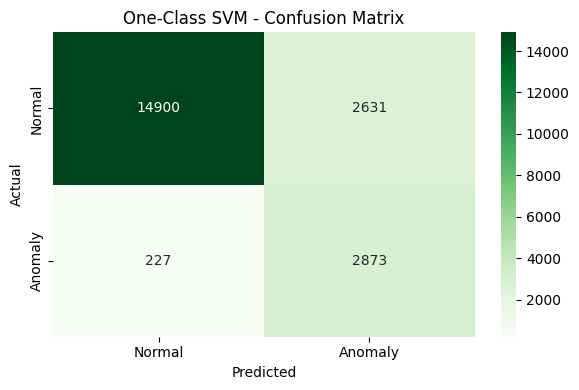

ROC-AUC Score: 0.9650


In [39]:
from sklearn.svm import OneClassSVM

# Train on normal data only (that's how One-Class SVM works)
X_normal = train_clean[train_clean['anomaly'] == 0][useful_sensors].values

svm = OneClassSVM(kernel='rbf', nu=0.15)
svm.fit(X_normal)

# Predict on all data
svm_preds = svm.predict(X_train)
svm_preds = (svm_preds == -1).astype(int)

print("=== One-Class SVM Results ===")
print(classification_report(y_true, svm_preds, target_names=['Normal', 'Anomaly']))

cm2 = confusion_matrix(y_true, svm_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
plt.title('One-Class SVM - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

svm_scores = svm.decision_function(X_train)
svm_auc = roc_auc_score(y_true, -svm_scores)
print(f"ROC-AUC Score: {svm_auc:.4f}")

Epoch 10/50 - Loss: 0.007605
Epoch 20/50 - Loss: 0.004531
Epoch 30/50 - Loss: 0.004366
Epoch 40/50 - Loss: 0.004228
Epoch 50/50 - Loss: 0.004172


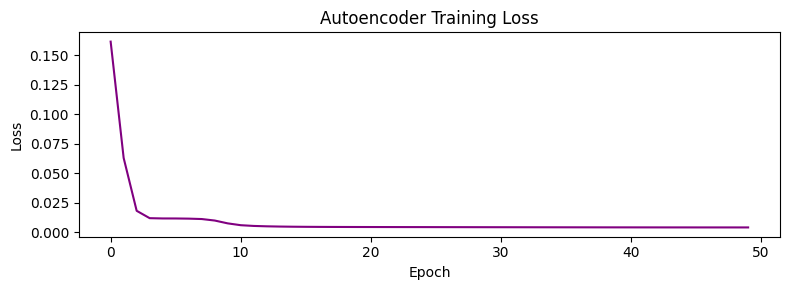

In [40]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Prepare data - train autoencoder on NORMAL data only
X_normal = train_clean[train_clean['anomaly'] == 0][useful_sensors].values
X_all    = train_clean[useful_sensors].values

# Convert to tensors
X_normal_tensor = torch.FloatTensor(X_normal)
X_all_tensor    = torch.FloatTensor(X_all)

# DataLoader
dataset    = TensorDataset(X_normal_tensor)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True)

# Define Autoencoder
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 8),
            nn.ReLU(),
            nn.Linear(8, 4),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(4, 8),
            nn.ReLU(),
            nn.Linear(8, input_dim)
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))

# Initialize
model     = Autoencoder(input_dim=len(useful_sensors))
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train
epochs = 50
losses = []
for epoch in range(epochs):
    epoch_loss = 0
    for (batch,) in dataloader:
        optimizer.zero_grad()
        output = model(batch)
        loss   = criterion(output, batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(dataloader)
    losses.append(avg_loss)
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/50 - Loss: {avg_loss:.6f}")

# Plot training loss
plt.figure(figsize=(8, 3))
plt.plot(losses, color='purple')
plt.title('Autoencoder Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.tight_layout()
plt.show()

Anomaly threshold: 0.008412

=== Autoencoder Results ===
              precision    recall  f1-score   support

      Normal       0.90      0.95      0.92     17531
     Anomaly       0.58      0.39      0.47      3100

    accuracy                           0.87     20631
   macro avg       0.74      0.67      0.70     20631
weighted avg       0.85      0.87      0.85     20631



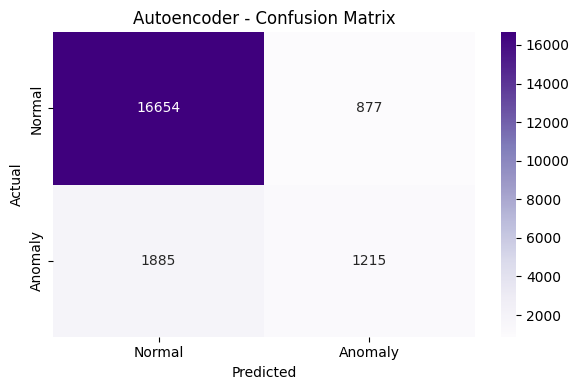

ROC-AUC Score: 0.7466


In [41]:
# Get reconstruction errors for all data
model.eval()
with torch.no_grad():
    reconstructed = model(X_all_tensor)
    errors = torch.mean((X_all_tensor - reconstructed) ** 2, dim=1).numpy()

# Set threshold - 95th percentile of normal data errors
normal_errors = errors[y_true == 0]
threshold = np.percentile(normal_errors, 95)
print(f"Anomaly threshold: {threshold:.6f}")

# Predict
ae_preds = (errors > threshold).astype(int)

print("\n=== Autoencoder Results ===")
print(classification_report(y_true, ae_preds, target_names=['Normal', 'Anomaly']))

# Confusion Matrix
cm3 = confusion_matrix(y_true, ae_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm3, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
plt.title('Autoencoder - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

ae_auc = roc_auc_score(y_true, errors)
print(f"ROC-AUC Score: {ae_auc:.4f}")

In [42]:
# Autonomous Decision Layer
def decision_system(rul, anomaly_score):
    if anomaly_score == 0:
        return "✅ NORMAL - No action needed"
    elif rul > 100:
        return "⚠️ WATCH - Monitor closely"
    elif rul > 50:
        return "🟠 WARNING - Schedule maintenance"
    elif rul > 30:
        return "🔴 CRITICAL - Prepare for shutdown"
    else:
        return "🚨 EMERGENCY - Shut subsystem / Alert ground station"

# Apply to training data
train_clean['iso_pred']  = preds
train_clean['decision']  = train_clean.apply(
    lambda row: decision_system(row['RUL'], row['iso_pred']), axis=1
)

# Show sample decisions
print(train_clean[['unit_id', 'cycle', 'RUL', 'anomaly', 'iso_pred', 'decision']].tail(20))

# Decision distribution
print("\nDecision Distribution:")
print(train_clean['decision'].value_counts())

       unit_id  cycle  RUL  anomaly  iso_pred  \
20611      100    181   19        1         0   
20612      100    182   18        1         1   
20613      100    183   17        1         0   
20614      100    184   16        1         0   
20615      100    185   15        1         0   
20616      100    186   14        1         0   
20617      100    187   13        1         1   
20618      100    188   12        1         1   
20619      100    189   11        1         1   
20620      100    190   10        1         1   
20621      100    191    9        1         1   
20622      100    192    8        1         1   
20623      100    193    7        1         1   
20624      100    194    6        1         1   
20625      100    195    5        1         1   
20626      100    196    4        1         1   
20627      100    197    3        1         1   
20628      100    198    2        1         1   
20629      100    199    1        1         1   
20630      100    20

In [43]:
pip install streamlit

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [44]:
# Dashboard is saved as a separate file: dashboard.py
# To run the dashboard, open a terminal and execute:
# python -m streamlit run "D:\AI ML MDS Project\dashboard.py"

print("Dashboard file: dashboard.py")
print("Run command: python -m streamlit run 'dashboard.py'")

Dashboard file: dashboard.py
Run command: python -m streamlit run 'dashboard.py'


In [45]:
import os
os.makedirs(r"D:\AI ML MDS Project", exist_ok=True)

dashboard_code = '''import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler

st.set_page_config(page_title="Space Mission Anomaly Dashboard", layout="wide")
st.title("AI-Based Anomaly Detection - Deep Space Mission Dashboard")

col_names = ["unit_id","cycle","op1","op2","op3"] + [f"s{i}" for i in range(1,22)]
train = pd.read_csv(r"D:\\CMAPSSData\\train_FD001.txt", sep=r"\\s+", header=None, names=col_names)

max_cycles = train.groupby("unit_id")["cycle"].max().reset_index()
max_cycles.columns = ["unit_id", "max_cycle"]
train = train.merge(max_cycles, on="unit_id")
train["RUL"] = train["max_cycle"] - train["cycle"]
train.drop(columns=["max_cycle"], inplace=True)

useful_sensors = ["s2","s3","s4","s7","s9","s11","s12","s14","s17","s20","s21"]
scaler = MinMaxScaler()
train[useful_sensors] = scaler.fit_transform(train[useful_sensors])
train["anomaly"] = (train["RUL"] <= 30).astype(int)

iso = IsolationForest(n_estimators=100, contamination=0.15, random_state=42)
iso.fit(train[useful_sensors])
train["iso_pred"] = (iso.predict(train[useful_sensors]) == -1).astype(int)

def decision(rul, pred):
    if pred == 0: return "NORMAL"
    elif rul > 100: return "WATCH"
    elif rul > 50: return "WARNING"
    elif rul > 30: return "CRITICAL"
    else: return "EMERGENCY"

train["decision"] = train.apply(lambda r: decision(r["RUL"], r["iso_pred"]), axis=1)

st.sidebar.header("Select Engine")
engine_id = st.sidebar.selectbox("Engine ID", sorted(train["unit_id"].unique()))
engine_df = train[train["unit_id"] == engine_id]

col1, col2, col3, col4 = st.columns(4)
last = engine_df.iloc[-1]
col1.metric("Engine ID", int(engine_id))
col2.metric("Total Cycles", int(engine_df["cycle"].max()))
col3.metric("Remaining Useful Life", int(last["RUL"]))
col4.metric("Status", last["decision"])

st.markdown("---")

st.subheader("Sensor Readings Over Time")
sensor = st.selectbox("Select Sensor", useful_sensors)
fig = px.line(engine_df, x="cycle", y=sensor, title=f"Engine {engine_id} - {sensor}",
              color_discrete_sequence=["tomato"])
st.plotly_chart(fig, use_container_width=True)

st.subheader("Anomaly Detection Timeline")
fig2 = px.scatter(engine_df, x="cycle", y="RUL", color="iso_pred",
                  color_discrete_map={0:"green", 1:"red"},
                  title=f"Engine {engine_id} - Anomaly Timeline (Red = Anomaly)")
st.plotly_chart(fig2, use_container_width=True)

st.subheader("Fleet-Wide Decision Distribution")
dist = train["decision"].value_counts().reset_index()
dist.columns = ["Decision", "Count"]
fig3 = px.bar(dist, x="Decision", y="Count", color="Decision",
              color_discrete_map={"NORMAL":"green","WATCH":"blue",
                                  "WARNING":"orange","CRITICAL":"red","EMERGENCY":"darkred"})
st.plotly_chart(fig3, use_container_width=True)
'''

with open(r"D:\AI ML MDS Project\dashboard.py", "w", encoding="utf-8") as f:
    f.write(dashboard_code)

print("Done! Now run in terminal:")
print('python -m streamlit run "D:\\AI ML MDS Project\\dashboard.py"')

Done! Now run in terminal:
python -m streamlit run "D:\AI ML MDS Project\dashboard.py"
